## Predicting Students' O-Level Mathematics Examination Scores


Introduction
This notebook aims to build machine learning models to predict students' O-level mathematics examination scores using the provided dataset. The objective is to identify weaker students prior to the examination, allowing the school to provide targeted support.

The dataset contains 15,001 rows and 18 columns with various student attributes including demographic information, academic history, extracurricular activities, and personal habits.

## Step 1: Import Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Feature selection
from sklearn.feature_selection import SelectKBest, f_regression

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")

In [2]:
# Load the dataset
data = pd.read_csv('data/regression_bonus_practice_data.csv')

# Display basic information
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
data.head()

Dataset Shape: (15900, 18)

First 5 rows:


,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,NaN,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


In [3]:
# Check data types and missing values
print("Data Info:")
data.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  object 
 3   CCA                 12071 non-null  object 
 4   learning_style      15900 non-null  object 
 5   student_id          15900 non-null  object 
 6   gender              15900 non-null  object 
 7   tuition             15900 non-null  object 
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  object 
 15  wake_time           15900 non-null  object

In [4]:
# Statistical summary of numerical features
print("Numerical Features Statistics:")
data.describe()

Numerical Features Statistics:


,index,number_of_siblings,final_test,n_male,n_female,age,hours_per_week,attendance_rate
count,15900.000000,15900.000000,15405.000000,15900.000000,15900.000000,15900.000000,15900.000000,15122.000000
mean,7949.500000,0.886541,67.165401,13.880000,8.906038,15.213459,10.312579,93.270268
std,4590.078975,0.751346,13.977879,6.552584,6.663852,1.758941,4.461861,7.984230
min,0.000000,0.000000,32.000000,0.000000,0.000000,-5.000000,0.000000,40.000000
25%,3974.750000,0.000000,56.000000,10.000000,4.000000,15.000000,7.000000,92.000000
50%,7949.500000,1.000000,68.000000,14.000000,8.000000,15.000000,9.000000,95.000000
75%,11924.250000,1.000000,78.000000,18.000000,13.000000,16.000000,14.000000,97.000000
max,15899.000000,2.000000,100.000000,31.000000,31.000000,16.000000,20.000000,100.000000


In [5]:
# Check for missing values
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
index                    0
number_of_siblings       0
direct_admission         0
CCA                   3829
learning_style           0
student_id               0
gender                   0
tuition                  0
final_test             495
n_male                   0
n_female                 0
age                      0
hours_per_week           0
attendance_rate        778
sleep_time               0
wake_time                0
mode_of_transport        0
bag_color                0
dtype: int64


## Step 3: Data Preprocessing


In [6]:
# Identify columns with missing values
missing_cols = data.columns[data.isnull().any()].tolist()
print("Columns with missing values:", missing_cols)

# Check the proportion of missing values
for col in missing_cols:
    missing_pct = data[col].isnull().mean() * 100
    print(f"{col}: {missing_pct:.2f}% missing")

Columns with missing values: ['CCA', 'final_test', 'attendance_rate']
CCA: 24.08% missing
final_test: 3.11% missing
attendance_rate: 4.89% missing


In [7]:
# Create a copy for preprocessing
df = data.copy()

# For columns with low missing values, we can impute
# For columns with high missing values, consider dropping or advanced imputation

# List of columns to keep for modeling (excluding target 'final_test')
feature_columns = [col for col in df.columns if col not in ['final_test', 'index']]

# Check columns with high missing values (>20%)
high_missing = []
for col in feature_columns:
    missing_pct = df[col].isnull().mean() * 100
    if missing_pct > 20:
        high_missing.append(col)
        print(f"{col}: {missing_pct:.2f}% missing")

CCA: 24.08% missing


## 3.2 Encode Categorical Variables


In [8]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Check unique values for each categorical column
for col in categorical_cols:
    print(f"\n{col} unique values: {df[col].unique()}")

Categorical columns: ['direct_admission', 'CCA', 'learning_style', 'student_id', 'gender', 'tuition', 'sleep_time', 'wake_time', 'mode_of_transport', 'bag_color']

direct_admission unique values: ['Yes' 'No']

CCA unique values: ['Sports' nan 'Clubs' 'Arts' 'ARTS' 'SPORTS' 'CLUBS' 'NONE']

learning_style unique values: ['Visual' 'Auditory']

student_id unique values: ['ACN2BE' 'FGXIIZ' 'B9AI9F' ... 'XKZ6VN' '2OU4UQ' 'D9OKLV']

gender unique values: ['Female' 'Male']

tuition unique values: ['No' 'Yes' 'Y' 'N']

sleep_time unique values: ['22:00' '22:30' '21:00' '21:30' '23:00' '23:30' '1:00' '0:30' '1:30'
 '2:30' '0:00' '2:00' '3:00']

wake_time unique values: ['6:00' '6:30' '5:00' '5:30' '7:00']

mode_of_transport unique values: ['private transport' 'public transport' 'walk']

bag_color unique values: ['yellow' 'green' 'white' 'red' 'blue' 'black']


In [9]:
# Standardize categorical values
# Combine similar values (e.g., 'Y' and 'Yes', 'N' and 'No')
for col in ['tuition', 'gender', 'direct_admission', 'mode_of_transport']:
    if col in df.columns:
        df[col] = df[col].replace({'Y': 'Yes', 'N': 'No'})
        
# For learning_style, ensure consistent capitalization
if 'learning_style' in df.columns:
    df['learning_style'] = df['learning_style'].str.upper()

# For CCA, ensure consistent capitalization
if 'CCA' in df.columns:
    df['CCA'] = df['CCA'].str.upper()

In [10]:
# Apply label encoding for ordinal/nominal categories
label_encoders = {}
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        # Fill NaN with 'Unknown' before encoding
        df[col] = df[col].fillna('Unknown')
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col} with {len(le.classes_)} classes")

Encoded direct_admission with 2 classes
Encoded CCA with 5 classes
Encoded learning_style with 2 classes
Encoded student_id with 15000 classes
Encoded gender with 2 classes
Encoded tuition with 2 classes
Encoded sleep_time with 13 classes
Encoded wake_time with 5 classes
Encoded mode_of_transport with 3 classes
Encoded bag_color with 6 classes


## 3.3 Handle Time Data


In [11]:
# Convert time columns to numeric
def time_to_minutes(time_str):
    """Convert time string to minutes since midnight"""
    if pd.isna(time_str) or time_str == 'Unknown':
        return np.nan
    try:
        # Handle formats like "22:00" or "0:00"
        parts = time_str.split(':')
        if len(parts) == 2:
            hours = int(parts[0])
            minutes = int(parts[1])
            return hours * 60 + minutes
        return np.nan
    except:
        return np.nan

# Convert sleep_time and wake_time
if 'sleep_time' in df.columns:
    df['sleep_time_minutes'] = df['sleep_time'].apply(time_to_minutes)
    
if 'wake_time' in df.columns:
    df['wake_time_minutes'] = df['wake_time'].apply(time_to_minutes)
    
# Calculate sleep duration
if 'sleep_time_minutes' in df.columns and 'wake_time_minutes' in df.columns:
    # Assume waking up is after sleeping (adjust if wake_time < sleep_time)
    df['sleep_duration'] = df['wake_time_minutes'] - df['sleep_time_minutes']
    # Adjust for cases where wake_time is earlier than sleep_time (overnight)
    df.loc[df['sleep_duration'] < 0, 'sleep_duration'] += 1440  # Add 24 hours in minutes
    
# Drop original time columns
df = df.drop(['sleep_time', 'wake_time'], axis=1)

## 3.4 Handle Anomalies


In [12]:
# Check for negative age values
print(f"Rows with negative age: {len(df[df['age'] < 0])}")
if len(df[df['age'] < 0]) > 0:
    df.loc[df['age'] < 0, 'age'] = df['age'].abs()

# Check for unrealistic age values (should be between 5-20 for students)
print(f"Age statistics:\n{df['age'].describe()}")

Rows with negative age: 5
Age statistics:
count    15900.000000
mean        15.216478
std          1.732630
min          4.000000
25%         15.000000
50%         15.000000
75%         16.000000
max         16.000000
Name: age, dtype: float64


## 3.5 Feature Engineering


In [13]:
# Calculate male-female ratio (avoid division by zero)
df['gender_ratio'] = df['n_male'] / (df['n_female'] + 1)  # Add 1 to avoid division by zero

# Total siblings count
if 'number_of_siblings' in df.columns:
    df['has_siblings'] = (df['number_of_siblings'] > 0).astype(int)

# Study efficiency (hours per week / age)
df['study_efficiency'] = df['hours_per_week'] / (df['age'] + 1)

# Attendance impact (combine attendance with hours)
df['study_effort'] = df['hours_per_week'] * (df['attendance_rate'] / 100)

# Sleep quality (if sleep_duration is available)
if 'sleep_duration' in df.columns:
    # Ideal sleep duration for students is 7-9 hours (420-540 minutes)
    df['sleep_quality'] = df['sleep_duration'].apply(
        lambda x: 1 if pd.notna(x) and 420 <= x <= 540 else 0 if pd.isna(x) else -1
    )

## Step 4: Exploratory Data Analysis


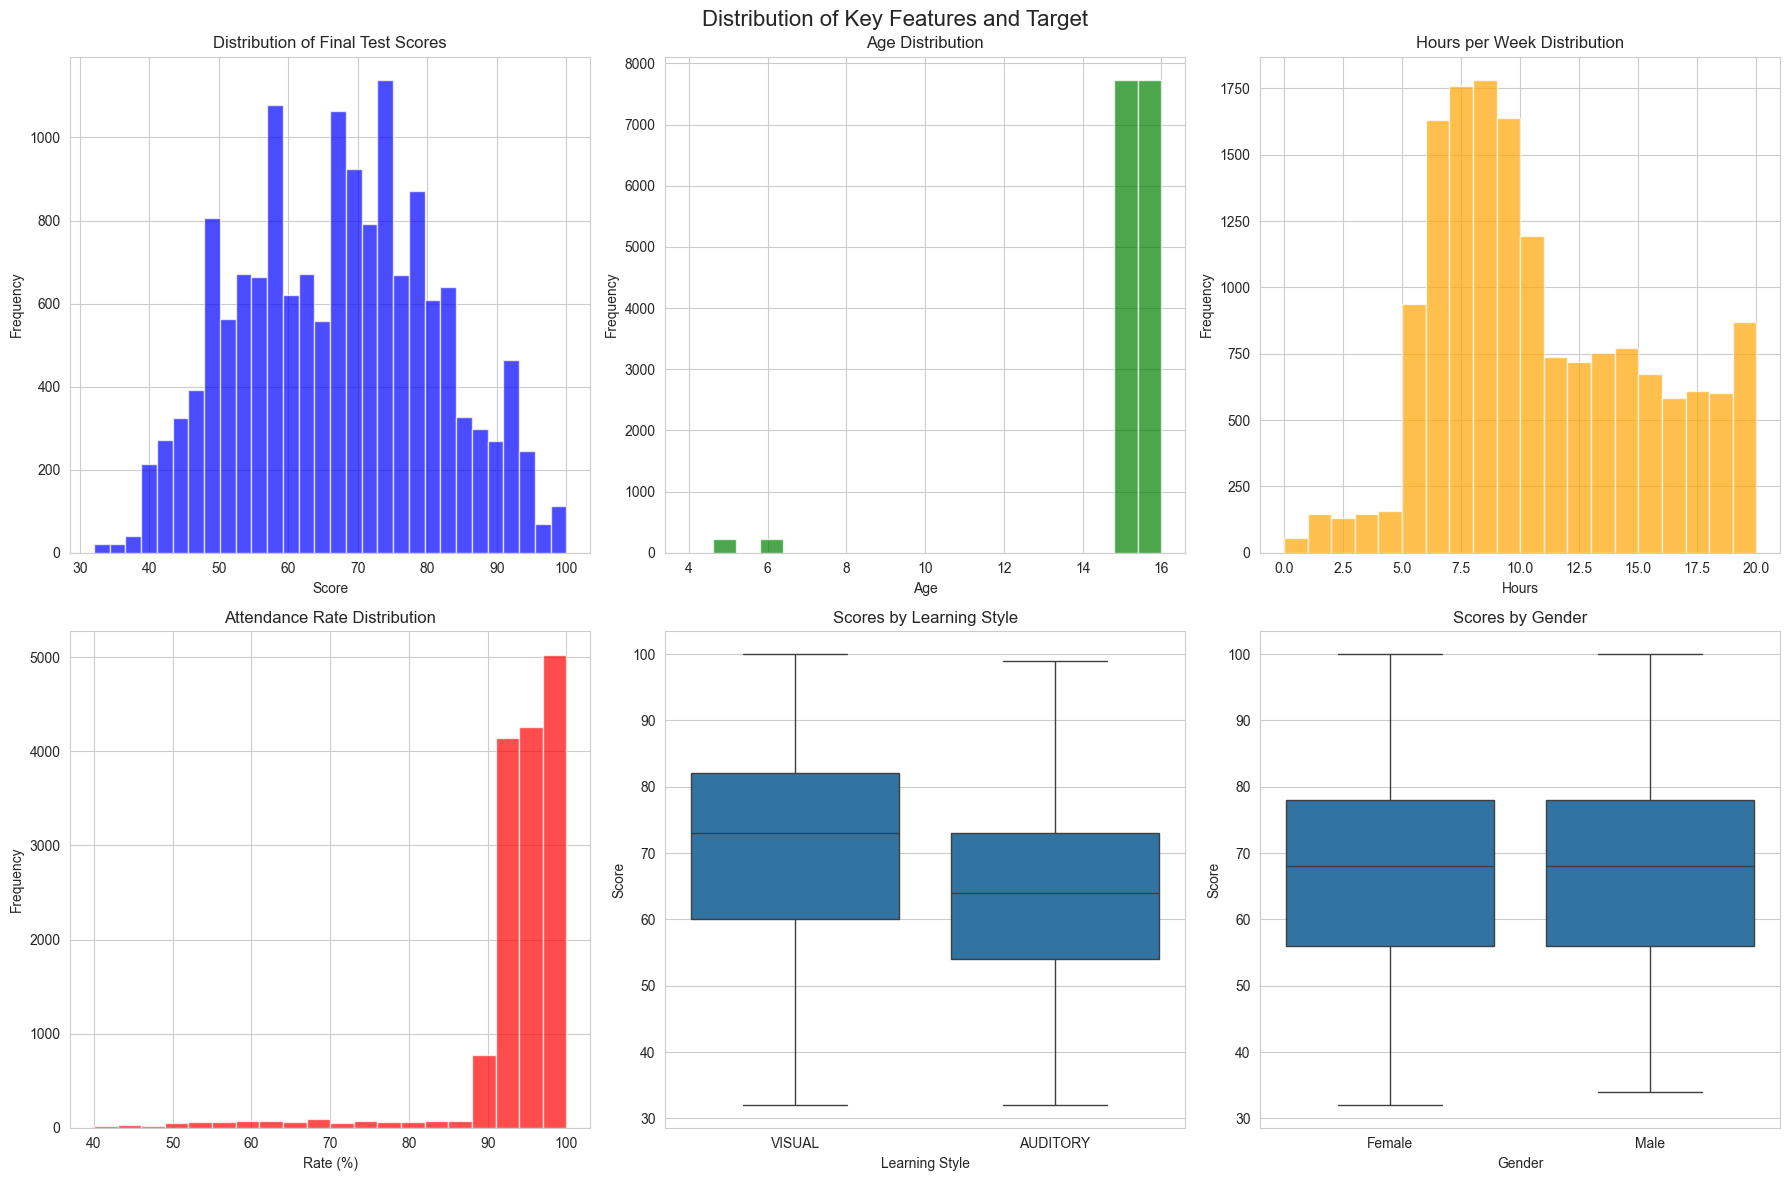

In [14]:
# Set up the figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution of Key Features and Target', fontsize=16)

# Target variable distribution
axes[0, 0].hist(df['final_test'].dropna(), bins=30, color='blue', alpha=0.7)
axes[0, 0].set_title('Distribution of Final Test Scores')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')

# Age distribution
axes[0, 1].hist(df['age'].dropna(), bins=20, color='green', alpha=0.7)
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# Hours per week
axes[0, 2].hist(df['hours_per_week'].dropna(), bins=20, color='orange', alpha=0.7)
axes[0, 2].set_title('Hours per Week Distribution')
axes[0, 2].set_xlabel('Hours')
axes[0, 2].set_ylabel('Frequency')

# Attendance rate
axes[1, 0].hist(df['attendance_rate'].dropna(), bins=20, color='red', alpha=0.7)
axes[1, 0].set_title('Attendance Rate Distribution')
axes[1, 0].set_xlabel('Rate (%)')
axes[1, 0].set_ylabel('Frequency')

# Boxplot of scores by learning style
if 'learning_style' in df.columns:
    # Create a copy and handle missing values for plotting
    plot_df = df[['learning_style', 'final_test']].dropna()
    if not plot_df.empty:
        # Decode the numeric labels back to strings for clear plotting
        learning_style_labels = {i: label for i, label in enumerate(label_encoders['learning_style'].classes_)}
        plot_df['learning_style_label'] = plot_df['learning_style'].map(learning_style_labels)
        
        sns.boxplot(ax=axes[1, 1], x='learning_style_label', y='final_test', data=plot_df)
        axes[1, 1].set_title('Scores by Learning Style')
        axes[1, 1].set_xlabel('Learning Style')
        axes[1, 1].set_ylabel('Score')
    else:
        print("Warning: No data available for learning_style boxplot.")

# Boxplot of scores by gender (similar fix)
if 'gender' in df.columns:
    plot_df = df[['gender', 'final_test']].dropna()
    if not plot_df.empty:
        gender_labels = {i: label for i, label in enumerate(label_encoders['gender'].classes_)}
        plot_df['gender_label'] = plot_df['gender'].map(gender_labels)
        
        sns.boxplot(ax=axes[1, 2], x='gender_label', y='final_test', data=plot_df)
        axes[1, 2].set_title('Scores by Gender')
        axes[1, 2].set_xlabel('Gender')
        axes[1, 2].set_ylabel('Score')
    else:
        print("Warning: No data available for gender boxplot.")

plt.tight_layout()
plt.show()

Top features correlated with final test score:
final_test            1.000000
attendance_rate       0.349375
CCA                   0.284394
learning_style        0.272315
tuition               0.269565
direct_admission      0.240523
age                   0.014843
gender_ratio          0.012365
index                 0.011807
gender                0.011779
student_id            0.005302
bag_color             0.003614
mode_of_transport    -0.004145
study_effort         -0.096954
study_efficiency     -0.131398
hours_per_week       -0.148254
n_male               -0.149152
n_female             -0.171978
number_of_siblings   -0.363767
has_siblings         -0.458126
sleep_time_minutes         NaN
wake_time_minutes          NaN
sleep_duration             NaN
sleep_quality              NaN
Name: final_test, dtype: float64


<Figure size 1400x1000 with 0 Axes>

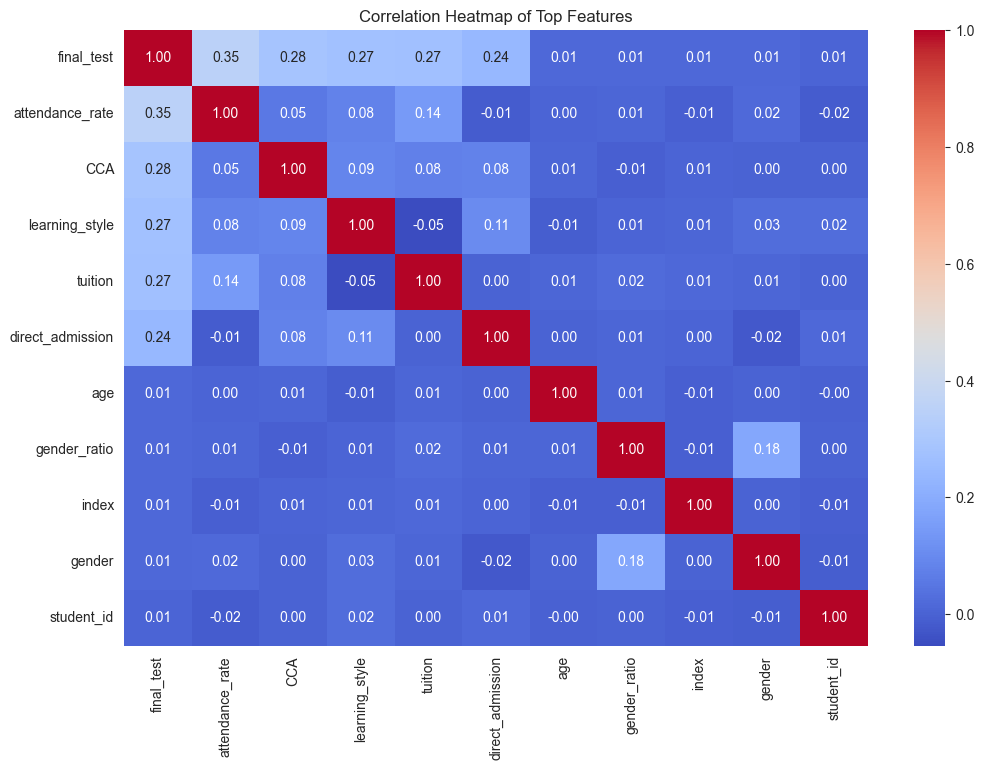

In [15]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target for correlation with features
numerical_cols_for_corr = [col for col in numerical_cols if col != 'final_test']
# Select top features based on correlation with target
corr_with_target = df[numerical_cols].corr()['final_test'].sort_values(ascending=False)

print("Top features correlated with final test score:")
print(corr_with_target)

# Create correlation heatmap for selected features
top_features = corr_with_target.head(15).index.tolist()
if 'final_test' in top_features:
    top_features.remove('final_test')
selected_cols = ['final_test'] + top_features[:10]
plt.figure(figsize=(12, 8))
sns.heatmap(df[selected_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Top Features')
plt.show()

## Step 5: Prepare Data for Modeling


In [16]:
# Prepare features and target
X = df.drop(['final_test', 'index', 'student_id'], axis=1)
y = df['final_test']

# Check for infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# Handle remaining missing values in features
# Separate numeric and categorical features
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# For numeric features, fill with median
for col in numeric_cols:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)

# For categorical features, fill with mode
for col in categorical_cols:
    mode_val = X[col].mode()[0] if not X[col].mode().empty else 'Unknown'
    X[col] = X[col].fillna(mode_val)

# Drop rows where target is missing
valid_indices = y.notna()
X = X[valid_indices]
y = y[valid_indices]

print(f"Final dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

Final dataset shape: (15405, 21)
Number of features: 21


## Step 6: Split Data and Build Pipelines


In [17]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 12324 samples
Test set: 3081 samples


In [18]:
# Identify feature types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

Number of numeric features: 21
Number of categorical features: 0


In [19]:
# Create preprocessor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- Define the improved preprocessor ---

# Numeric pipeline: Impute with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute with most frequent value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# --- Define models with the improved pipeline ---
models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', DecisionTreeRegressor(random_state=42, max_depth=15))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42, n_estimators=100, max_depth=15))
    ])
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    results[name] = {
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae
    }
    
    print(f"Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")
    print(f"Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}")


Training Linear Regression...
Train R²: 0.5590, Test R²: 0.5571
Train RMSE: 9.2901, Test RMSE: 9.2722
Train MAE: 7.4026, Test MAE: 7.4135

Training Decision Tree...
Train R²: 0.9023, Test R²: 0.5822
Train RMSE: 4.3714, Test RMSE: 9.0058
Train MAE: 2.6431, Test MAE: 6.2467

Training Random Forest...
Train R²: 0.9124, Test R²: 0.7343
Train RMSE: 4.1407, Test RMSE: 7.1819
Train MAE: 3.0653, Test MAE: 5.2601


## Step 7: Hyperparameter Tuning


In [ ]:
# Hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [10, 15, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(
    rf_pipeline, 
    param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("\nPerforming Grid Search for Random Forest...")
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation R²: {grid_search.best_score_:.4f}")

# Use the best model
best_rf = grid_search.best_estimator_
y_test_pred_best = best_rf.predict(X_test)
best_test_r2 = r2_score(y_test, y_test_pred_best)
best_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_best))

print(f"Best model Test R²: {best_test_r2:.4f}")
print(f"Best model Test RMSE: {best_test_rmse:.4f}")


Performing Grid Search for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


## Step 8: Feature Importance Analysis


In [ ]:
## Step 8: Feature Importance Analysis

# Get feature importance from best Random Forest model
def get_feature_importance_from_pipeline(pipeline, preprocessor, feature_names_original=None):
    """
    Extract feature importance from a fitted pipeline.
    
    Parameters:
    - pipeline: Fitted pipeline with RandomForestRegressor
    - preprocessor: Fitted ColumnTransformer
    - feature_names_original: Original column names (optional)
    
    Returns:
    - DataFrame with feature names and importance scores
    """
    try:
        # Get the Random Forest model from the pipeline
        if hasattr(pipeline, 'named_steps'):
            rf_model = pipeline.named_steps['regressor']
        else:
            rf_model = pipeline
        
        # Check if model has feature_importances_
        if not hasattr(rf_model, 'feature_importances_'):
            print("Model does not have feature_importances_ attribute")
            return None
        
        importances = rf_model.feature_importances_
        
        # Get feature names from preprocessor
        feature_names = []
        
        # Get numeric feature names
        if hasattr(preprocessor, 'named_transformers_'):
            # Numeric features
            num_transformer = preprocessor.named_transformers_.get('num')
            if num_transformer is not None:
                # Get the actual numeric column names
                num_features = preprocessor.transformers_[0][2]
                if isinstance(num_features, list):
                    feature_names.extend(num_features)
                else:
                    feature_names.extend(num_features.tolist())
            
            # Categorical features - get one-hot encoded names
            cat_transformer = preprocessor.named_transformers_.get('cat')
            if cat_transformer is not None:
                cat_features = preprocessor.transformers_[1][2]
                if hasattr(cat_transformer, 'get_feature_names_out'):
                    try:
                        # Get original categorical column names
                        if isinstance(cat_features, list):
                            cat_names = cat_transformer.get_feature_names_out(cat_features)
                        else:
                            cat_names = cat_transformer.get_feature_names_out(cat_features.tolist())
                        feature_names.extend(cat_names)
                    except:
                        # Fallback: use generic names
                        cat_encoder = cat_transformer.named_steps.get('onehot')
                        if cat_encoder is not None:
                            n_cat_features = len(cat_encoder.categories_) if hasattr(cat_encoder, 'categories_') else 0
                            feature_names.extend([f'cat_{i}' for i in range(n_cat_features)])
                        else:
                            feature_names.extend([f'cat_feature_{i}' for i in range(len(importances) - len(feature_names))])
        
        # If feature_names is empty, use generic names
        if len(feature_names) == 0 and feature_names_original is not None:
            feature_names = feature_names_original
        elif len(feature_names) == 0:
            feature_names = [f'feature_{i}' for i in range(len(importances))]
        
        # Ensure lengths match
        if len(feature_names) != len(importances):
            print(f"Warning: feature_names ({len(feature_names)}) != importances ({len(importances)})")
            # Truncate or pad
            if len(feature_names) > len(importances):
                feature_names = feature_names[:len(importances)]
            else:
                feature_names.extend([f'feature_{i}' for i in range(len(importances) - len(feature_names))])
        
        # Create DataFrame
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)
        
        return importance_df
        
    except Exception as e:
        print(f"Error extracting feature importance: {e}")
        return None

# After training the best model, extract feature importance
if best_rf is not None:
    # Get feature names from the training data
    feature_names_original = X_train.columns.tolist()
    
    importance_df = get_feature_importance_from_pipeline(
        best_rf, 
        preprocessor,
        feature_names_original
    )
    
    if importance_df is not None:
        print("\nTop 15 Feature Importances:")
        print(importance_df.head(15))
        
        # Plot feature importances
        plt.figure(figsize=(12, 8))
        top_n = 15
        top_features = importance_df.head(top_n)
        plt.barh(top_features['feature'], top_features['importance'])
        plt.xlabel('Importance')
        plt.title(f'Top {top_n} Feature Importances')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("Could not extract feature importance.")

## Step 9: Model Comparison and Evaluation


In [ ]:
# Add tuned Random Forest to results
results['Tuned Random Forest'] = {
    'Train R²': r2_score(y_train, best_rf.predict(X_train)),
    'Test R²': best_test_r2,
    'Train RMSE': np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train))),
    'Test RMSE': best_test_rmse,
    'Train MAE': mean_absolute_error(y_train, best_rf.predict(X_train)),
    'Test MAE': mean_absolute_error(y_test, y_test_pred_best)
}

# Create comparison dataframe
comparison_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(comparison_df)

# Visualization of model performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² scores
comparison_df[['Train R²', 'Test R²']].plot(kind='bar', ax=axes[0])
axes[0].set_title('R² Scores Comparison')
axes[0].set_ylabel('R² Score')
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(comparison_df.index, rotation=45, ha='right')

# RMSE scores
comparison_df[['Train RMSE', 'Test RMSE']].plot(kind='bar', ax=axes[1])
axes[1].set_title('RMSE Scores Comparison')
axes[1].set_ylabel('RMSE')
axes[1].legend(loc='upper right')
axes[1].set_xticklabels(comparison_df.index, rotation=45, ha='right')

# MAE scores
comparison_df[['Train MAE', 'Test MAE']].plot(kind='bar', ax=axes[2])
axes[2].set_title('MAE Scores Comparison')
axes[2].set_ylabel('MAE')
axes[2].legend(loc='upper right')
axes[2].set_xticklabels(comparison_df.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Step 10: Model Selection and Final Evaluation


In [ ]:
# Select the best model based on test R²
best_model_name = comparison_df['Test R²'].idxmax()
best_model_r2 = comparison_df.loc[best_model_name, 'Test R²']
best_model_rmse = comparison_df.loc[best_model_name, 'Test RMSE']

print(f"\nBest Model: {best_model_name}")
print(f"Test R²: {best_model_r2:.4f}")
print(f"Test RMSE: {best_model_rmse:.4f}")

# Visualize predictions vs actual for the best model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of predicted vs actual (test set)
if best_model_name == 'Tuned Random Forest':
    y_pred_best = best_rf.predict(X_test)
else:
    y_pred_best = models[best_model_name].predict(X_test)

ax1.scatter(y_test, y_pred_best, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Scores')
ax1.set_ylabel('Predicted Scores')
ax1.set_title(f'{best_model_name}: Predicted vs Actual')

# Residual plot
residuals = y_test - y_pred_best
ax2.scatter(y_pred_best, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Scores')
ax2.set_ylabel('Residuals')
ax2.set_title(f'{best_model_name}: Residual Plot')

plt.tight_layout()
plt.show()

# Histogram of residuals
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, alpha=0.7, color='blue')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title(f'{best_model_name}: Distribution of Residuals')
plt.show()

## Step 11: Identify Weaker Students


In [ ]:
# Use the best model to predict scores for all students
# and identify those who might need additional support

# Predict for all students
all_predictions = best_rf.predict(X) if best_model_name == 'Tuned Random Forest' else models[best_model_name].predict(X)

# Create dataframe with predictions
student_predictions = pd.DataFrame({
    'student_id': df['student_id'][valid_indices],
    'actual_score': y,
    'predicted_score': all_predictions,
    'score_gap': y - all_predictions  # Negative if overpredicted, positive if underpredicted
})

# Identify students at risk (predicted below threshold)
threshold = 50  # Set threshold based on school's criteria
at_risk_students = student_predictions[student_predictions['predicted_score'] < threshold]
at_risk_students = at_risk_students.sort_values('predicted_score')

print(f"\nNumber of at-risk students (predicted < {threshold}): {len(at_risk_students)}")
print("\nTop 10 at-risk students:")
print(at_risk_students.head(10))

# Distribution of predicted scores
plt.figure(figsize=(10, 6))
plt.hist(student_predictions['predicted_score'], bins=30, alpha=0.7, color='green')
plt.axvline(x=threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Predicted Score')
plt.ylabel('Number of Students')
plt.title('Distribution of Predicted Scores')
plt.legend()
plt.show()

## Step 12: Save the Best Model


In [ ]:
import joblib

# Save the best model
if best_model_name == 'Tuned Random Forest':
    best_model = best_rf
else:
    best_model = models[best_model_name]

joblib.dump(best_model, 'best_student_performance_model.pkl')
print("Best model saved as 'best_student_performance_model.pkl'")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'test_r2': best_model_r2,
    'test_rmse': best_model_rmse,
    'features': X.columns.tolist(),
    'threshold': threshold,
    'n_at_risk': len(at_risk_students)
}

joblib.dump(metadata, 'model_metadata.pkl')
print("Model metadata saved as 'model_metadata.pkl'")

## Summary and Conclusion


In [ ]:
# Final summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"\n1. Best Performing Model: {best_model_name}")
print(f"   - Test R²: {best_model_r2:.4f}")
print(f"   - Test RMSE: {best_model_rmse:.4f}")

print(f"\n2. Number of Students Analyzed: {len(student_predictions)}")
print(f"   - Students at Risk (predicted < {threshold}): {len(at_risk_students)}")
print(f"   - Percentage of Students at Risk: {len(at_risk_students)/len(student_predictions)*100:.2f}%")

print("\n3. Key Features Influencing Performance:")
top_features = feature_importance_df.head(5)
for _, row in top_features.iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print("\n4. Recommendations:")
print("   - Focus intervention efforts on the identified at-risk students")
print("   - Consider monitoring the top 5-10 features for early warning signs")
print("   - Regularly update predictions as new data becomes available")